# Insights de questionário escolar

Exploração de dados de informações de um questionário aplicado à alunos de primeiro ano (simulação).

## Organização dos dados

In [98]:
import pandas as pd
import numpy as np
questionario = pd.read_csv("../data/questionario_estudantil.csv", index_col=0)
print(questionario.head())

   Turma Genero  Idade  Altura  Peso  Filhos Fuma Tolerancia  Exercicios  \
Id                                                                         
1      A      F     17    1.60  60.5       2  NAO          P           0   
2      A      F     18    1.69  55.0       1  NAO          M           0   
3      A      M     18    1.85  72.8       2  NAO          P           5   
4      A      M     25    1.85  80.9       2  NAO          P           5   
5      A      F     19    1.58  55.0       1  NAO          M           2   

    Cinema OpCine  TV OpTV  
Id                          
1        1      B  16    R  
2        1      B   7    R  
3        2      M  15    R  
4        2      B  20    R  
5        2      B   5    R  


## Tabela de frequência para variável Gênero

In [99]:
# count the categories of "Genero" column, name the new column "Frequencia" and print the result
genero_frequencia = questionario[["Genero"]].value_counts().reset_index()
genero_frequencia["percentual"] = (genero_frequencia["count"] / genero_frequencia["count"].sum()) * 100
genero_pivot = genero_frequencia.pivot_table(index="Genero", values=["count","percentual"], aggfunc="sum", margins=True, margins_name="Total")
genero_pivot.columns = ["Frequencia", "Percentual"]
print(genero_pivot)

        Frequencia  Percentual
Genero                        
F               37        74.0
M               13        26.0
Total           50       100.0


### Resultado
Observa-se que 74% dos alunos são do gênero feminino.

## Tabela de frequência para variável Idade

In [102]:
idades_frequencia = pd.DataFrame({'Idade': [idade for idade in range(questionario["Idade"].min(), questionario["Idade"].max() + 1)]})
idades_frequencia["Frequencia"] = idades_frequencia["Idade"].map(questionario["Idade"].value_counts()).fillna(0).astype(int)
idades_frequencia["Percentual"] = (idades_frequencia["Frequencia"] / idades_frequencia["Frequencia"].sum()) * 100
idades_frequencia["Acumulado"] = idades_frequencia["Percentual"].cumsum()
idades_frequencia = idades_frequencia.pivot_table(index="Idade", values=["Frequencia", "Percentual", "Acumulado"], aggfunc="sum", margins=True, margins_name="Total", sort=False)
# not display acumulado for the total row
idades_frequencia.loc["Total", "Acumulado"] = np.nan
print(idades_frequencia)

       Frequencia  Percentual  Acumulado
Idade                                   
17              9        18.0       18.0
18             22        44.0       62.0
19              7        14.0       76.0
20              4         8.0       84.0
21              3         6.0       90.0
22              0         0.0       90.0
23              2         4.0       94.0
24              1         2.0       96.0
25              2         4.0      100.0
Total          50       100.0        NaN


## Distribuição da variável Peso

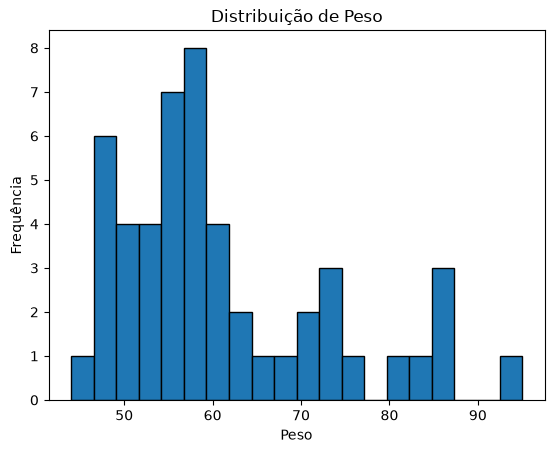

In [104]:
import matplotlib.pyplot as plt

coluna_peso = questionario["Peso"]
plt.hist(coluna_peso, bins=20, edgecolor='black')
plt.xlabel('Peso')
plt.ylabel('Frequência')
plt.title('Distribuição de Peso')
plt.show()

## Distribuição da variável Altura

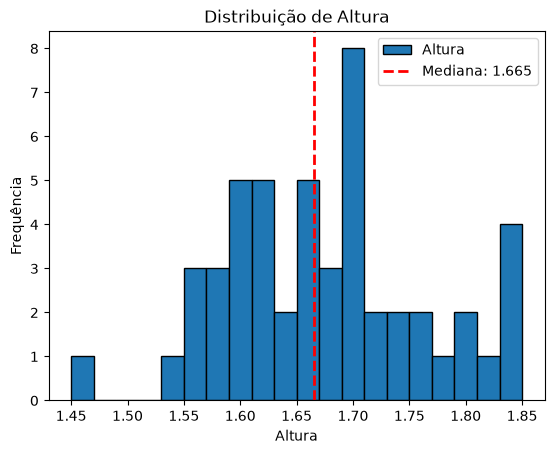

In [108]:
# determinar mediana
mediana_altura = questionario["Altura"].median()

# distribuição de altura e representação da mediana
questionario["Altura"].plot(kind="hist",bins=20, edgecolor="black")
plt.xlabel("Altura")
plt.ylabel("Frequência")
plt.title("Distribuição de Altura")
plt.axvline(mediana_altura, color="red", linestyle="dashed", linewidth=2, label=f"Mediana: {mediana_altura}")
plt.legend()
plt.show()